### LLM Architecture

In [1]:
#GPT configs to be used later
GPT_CONFIG_124M = {
    "vocab_size" : 50257, #GPT-2's vocab size (to be used by BPE tokenizer)
    "context_length": 1024, #max number of tokens, # of position vectors 
    "emb_dim": 768, #embedding dimension 
    "num_heads": 12, #number of attention heads, like different attention mechanisms analyzed 
    "num_layers": 12, #transformer blocks(will learn)
    "drop_rate": 0.1, #drop 10% randomly during training to prevent overfitting
    "qkv_bias": False, #whether to include bias(will learn more too)
}

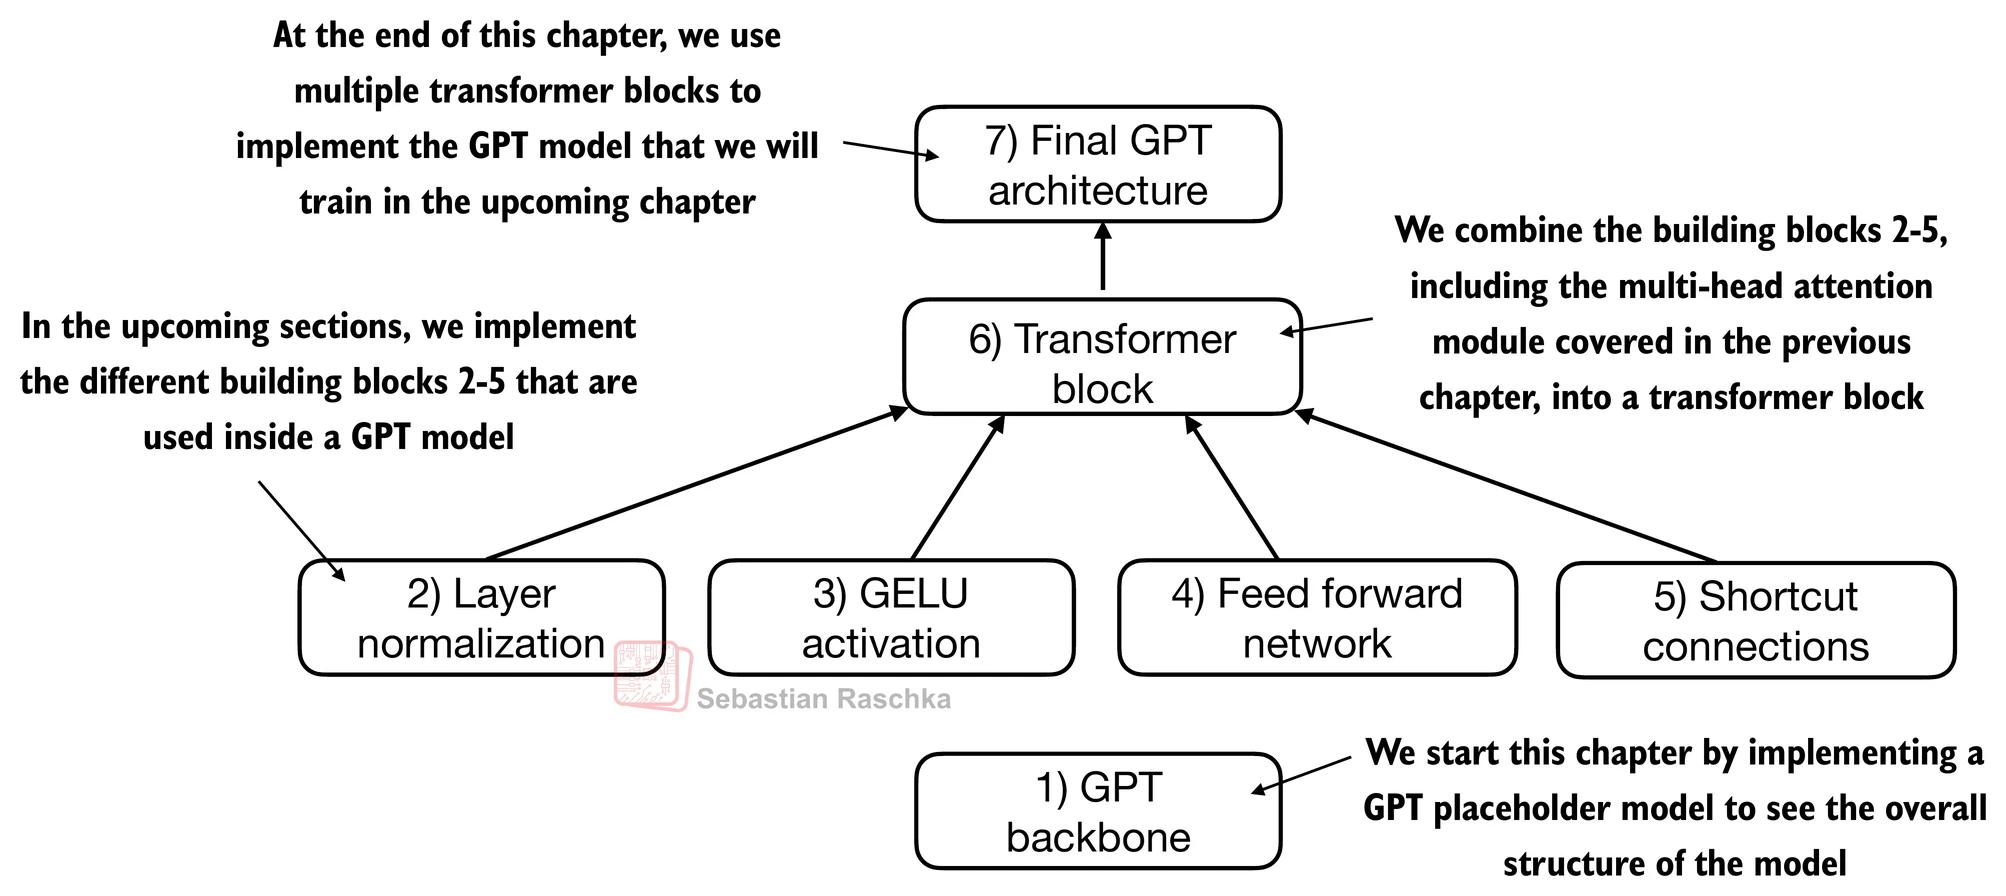


## **Prepare Data** 
- tokenize (tiktoken)
- turn to tensor (torch.tensor)


In [2]:
import tiktoken 
import torch
import torch.nn as nn

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Ever day holds a"

#tokenize text then convert to tensor and stack them to create input data
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[ 6109,  3626,  6100,   345],
        [23921,  1110,  6622,   257]])


In [3]:
torch.manual_seed(123)
from GPT_Model_architecture_class import DummyGPTmodel

model = DummyGPTmodel(GPT_CONFIG_124M)
logits = model(batch)
print(logits.shape)
print(logits)

torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-0.0678,  0.5159,  0.1443,  ..., -0.2633,  0.0214,  0.8341],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


[2,4,50257]

2-> batch size, # of rows/samples (txt1, txt2)
4 -> length per sample (4 words)
50257 -> number of unique words/subwords that GPT2 tokenizer has 

## **Normalizing activations with layer normalization**
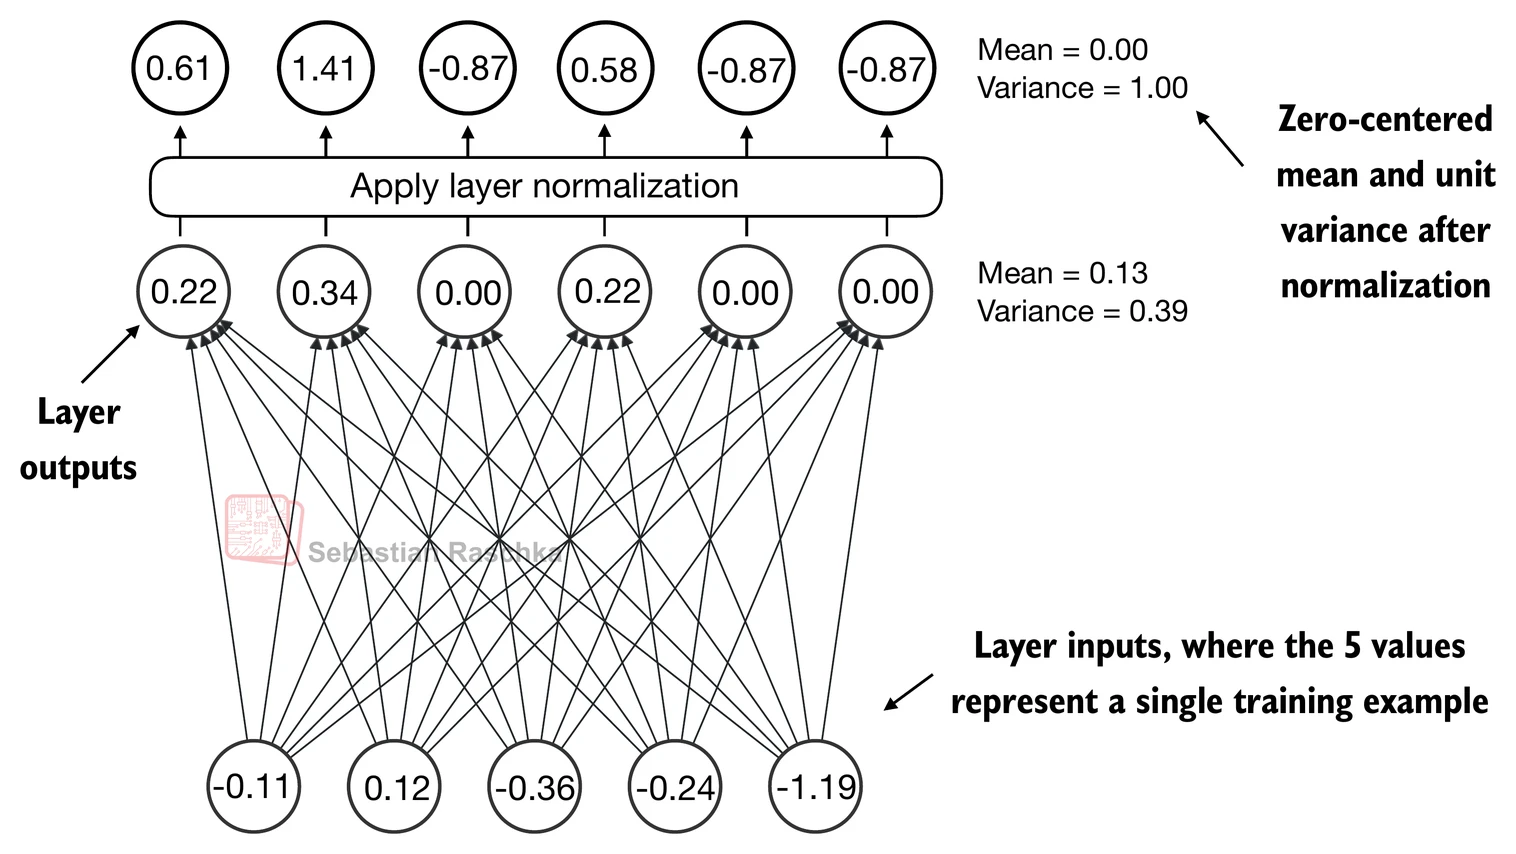

In [4]:
torch.manual_seed(123)

batch_example = torch.randn(2,5)
print(batch_example) #2 samples, 5 features each


layer = nn.Sequential( #sequential container to stack layers together
    nn.Linear(5,6),  #5 input features, 6 output features #linear transformation of the input data
    nn.ReLU() #filter, activation function only allow positive values through
)
out = layer(batch_example)
print(out) #output of the sequential layer, 2 samples, 6 features each

tensor([[-0.1115,  0.1204, -0.3696, -0.2404, -1.1969],
        [ 0.2093, -0.9724, -0.7550,  0.3239, -0.1085]])
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [5]:
#look at the current mean and variance of the output

mean = out.mean(dim=-1, keepdim=True) #mean across features for each sample
var = out.var(dim=-1, keepdim=True) #variance across features for each sample
print("Mean before normalization:", mean)
print("Variance before normalization:", var)


Mean before normalization: tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance before normalization: tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


why dim = -1

When data becomes multi-dimensional : (batch_size, num_tokens, emb_size)
we want to calculate mean and variance across the embedding dimension (features) for each token in each sample.
dim=-1 means we are calculating mean and variance across the last dimension of the tensor, which is the embedding dimension in this case.
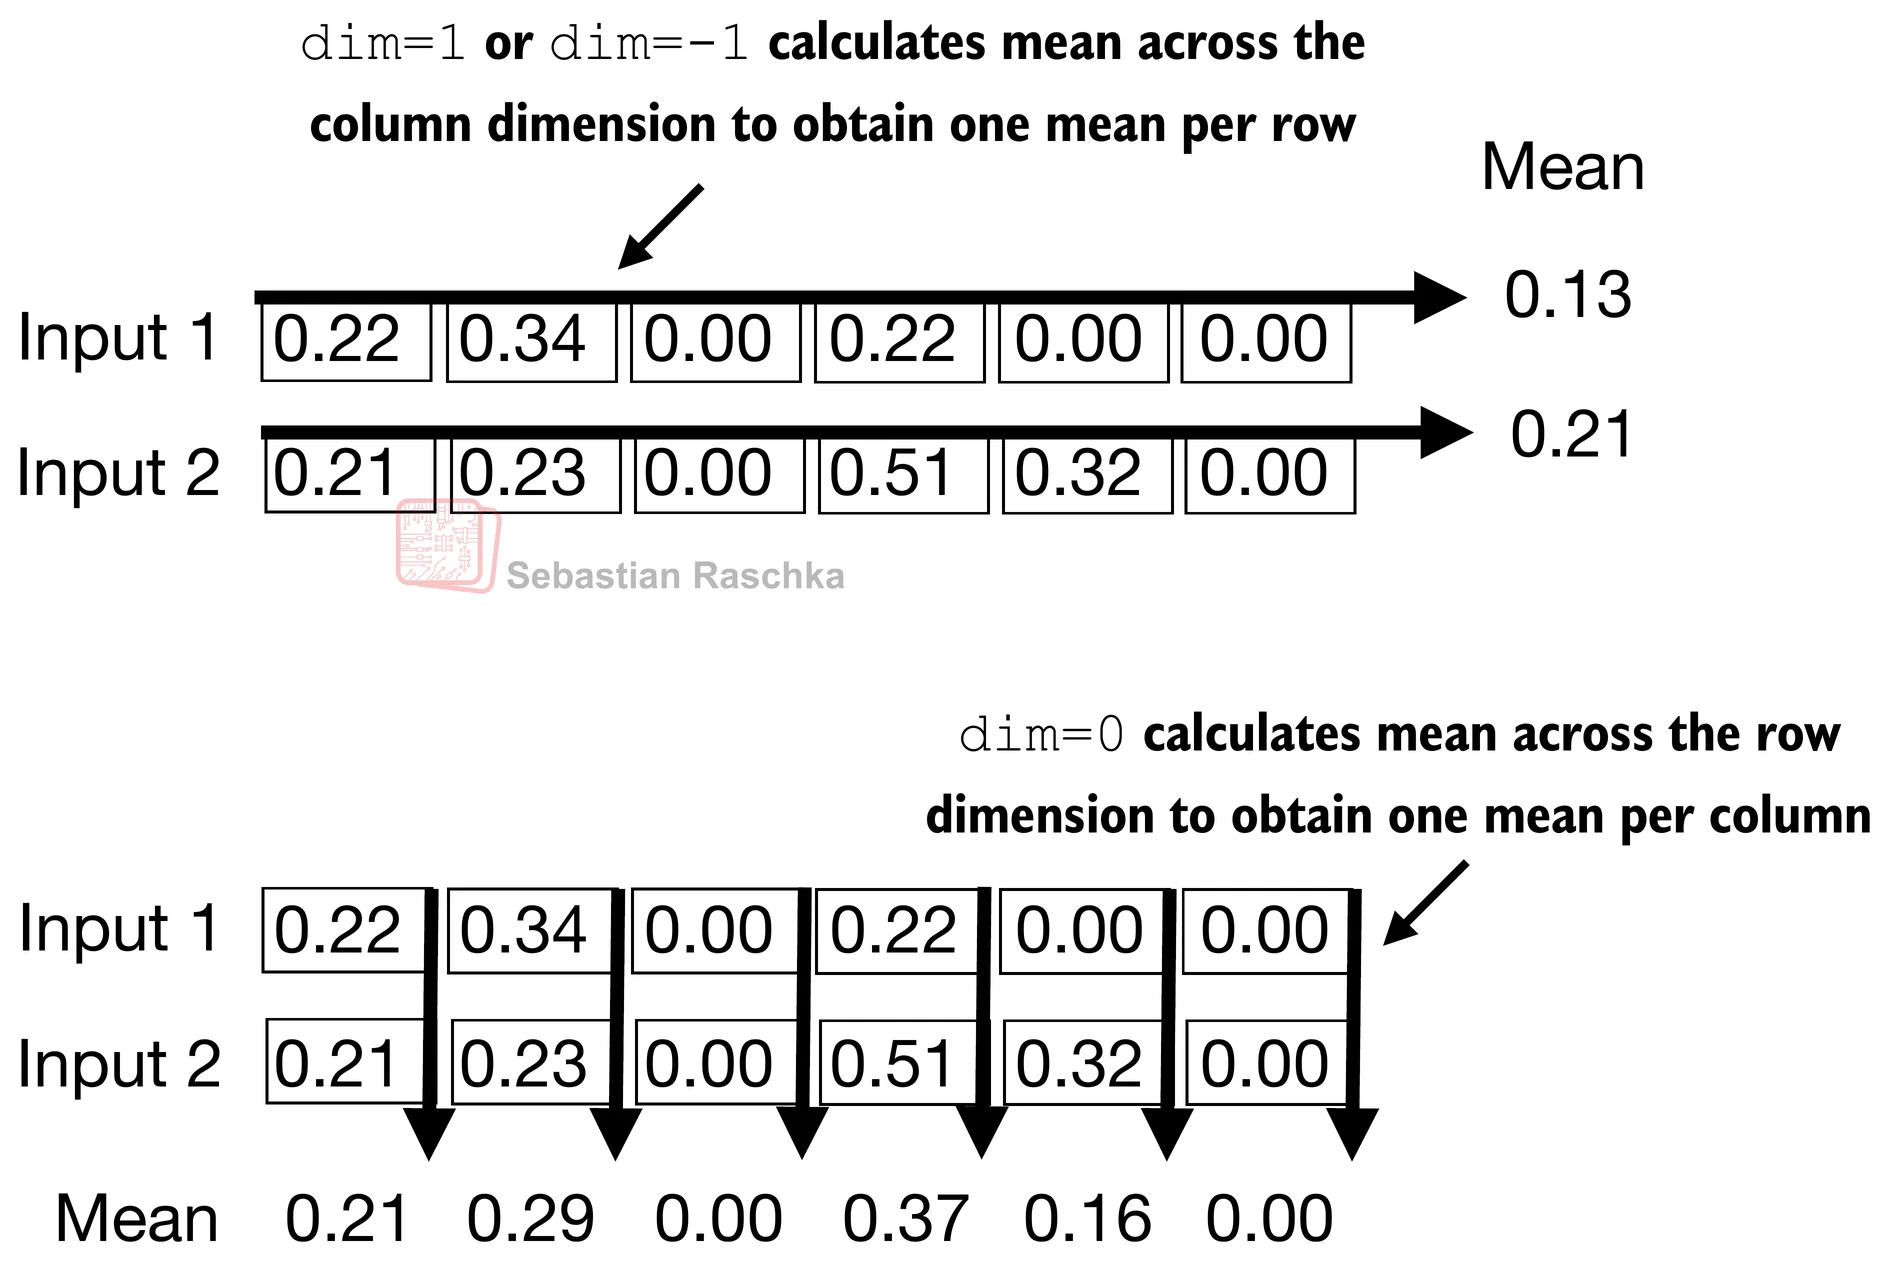

In [6]:
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True) #mean across features for each sample
var = out_norm.var(dim=-1, keepdim=True) #variance across features for each sample
print("Normalized output:", out_norm)
print("Mean after normalization:", mean)
print("Variance after normalization:", var)

Normalized output: tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean after normalization: tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance after normalization: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


#### Using Class with actual batch

In [7]:
from GPT_Model_architecture_class import LayerNorm

ln = LayerNorm(6) #6 features in the input
out_ln = ln(out)

mean = out_ln.mean(dim=-1, keepdim=True) #mean across features for each sample
var = out_ln.var(dim=-1, keepdim=True) #variance across features for each
print("Output after LayerNorm:", out_ln)
print("Mean after LayerNorm:", mean)
print("Variance after LayerNorm:", var)


Output after LayerNorm: tensor([[ 0.6157,  1.4123, -0.8717,  0.5871, -0.8717, -0.8717],
        [-0.0189,  0.1121, -1.0875,  1.5171,  0.5647, -1.0875]],
       grad_fn=<AddBackward0>)
Mean after LayerNorm: tensor([[-1.9868e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
Variance after LayerNorm: tensor([[0.9996],
        [0.9997]], grad_fn=<VarBackward0>)


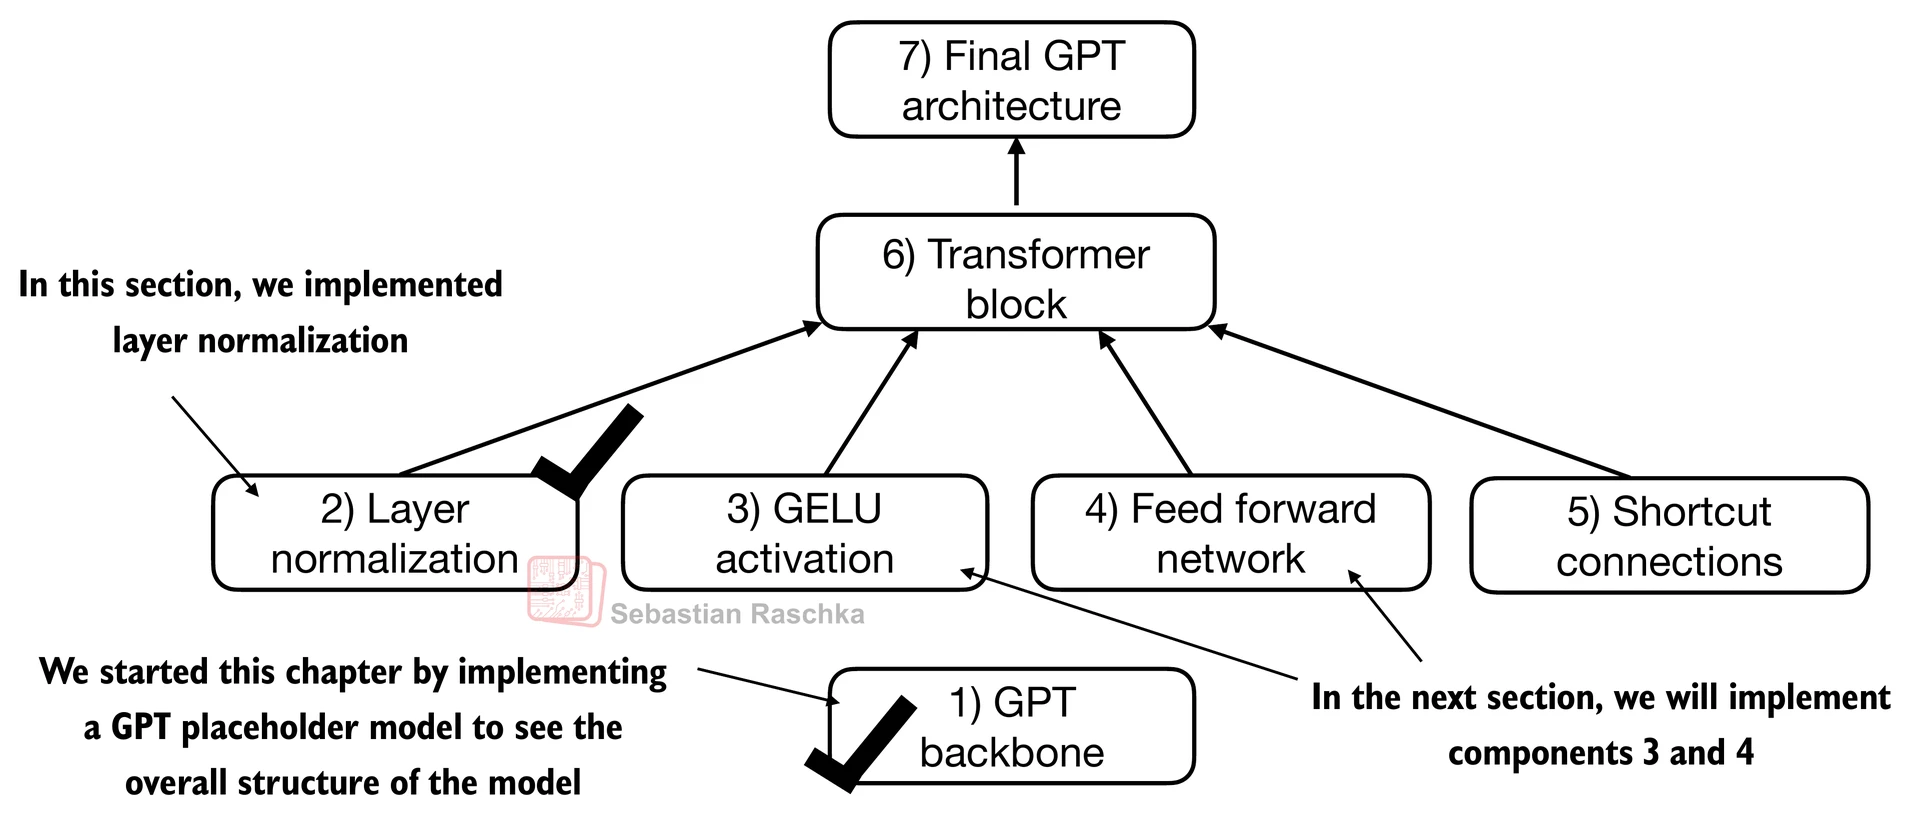

## **Feed forward network with GELU activations**

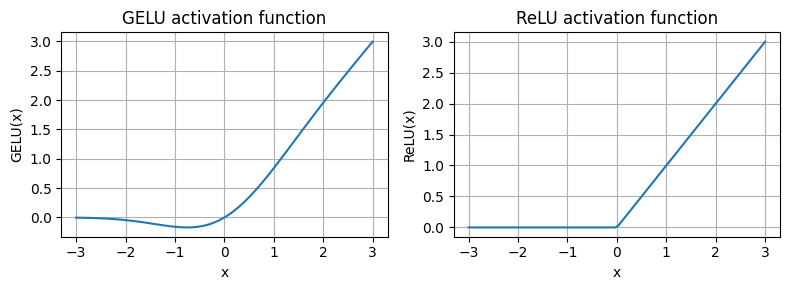
Using GELU instead of Relu allows some negative through helping the model learn more complex patterns 

In [8]:
print(GPT_CONFIG_124M["emb_dim"])

768


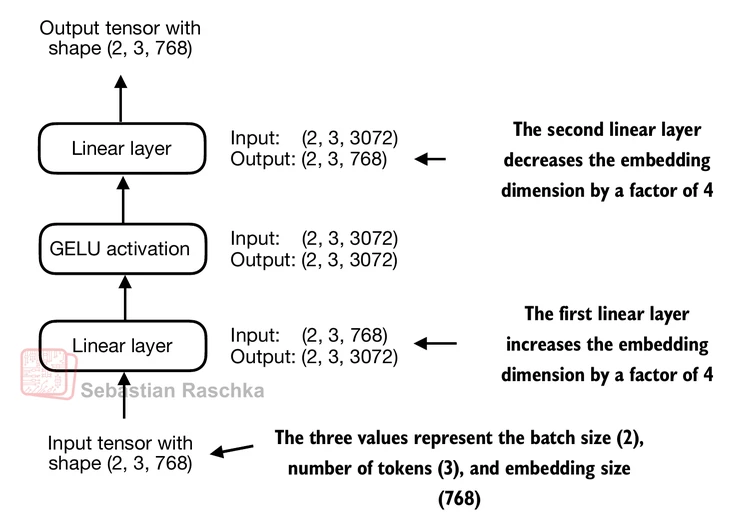

In [9]:
from GPT_Model_architecture_class import FeedForward

ffn = FeedForward(GPT_CONFIG_124M)

x = torch.rand(2,3, 768) #batch of 2 samples, 3 tokens per sample, 768 embedding dimension
out = ffn(x)
print(out.shape) #should be (2,3,768) since we project back to the same dimension

torch.Size([2, 3, 768])


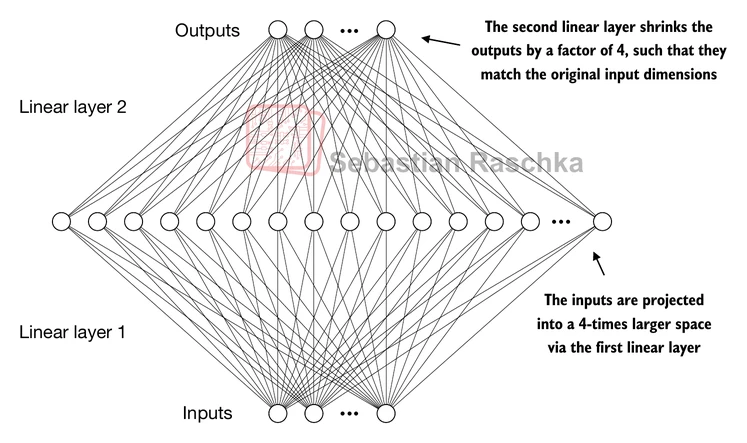
expansion of embedding dimensions internally inside the forward feed allows for richer representation of the layer therefore more learning. each goes thorugh its own linear equation and GELU (more mathematical view points) before shrinking data back down 

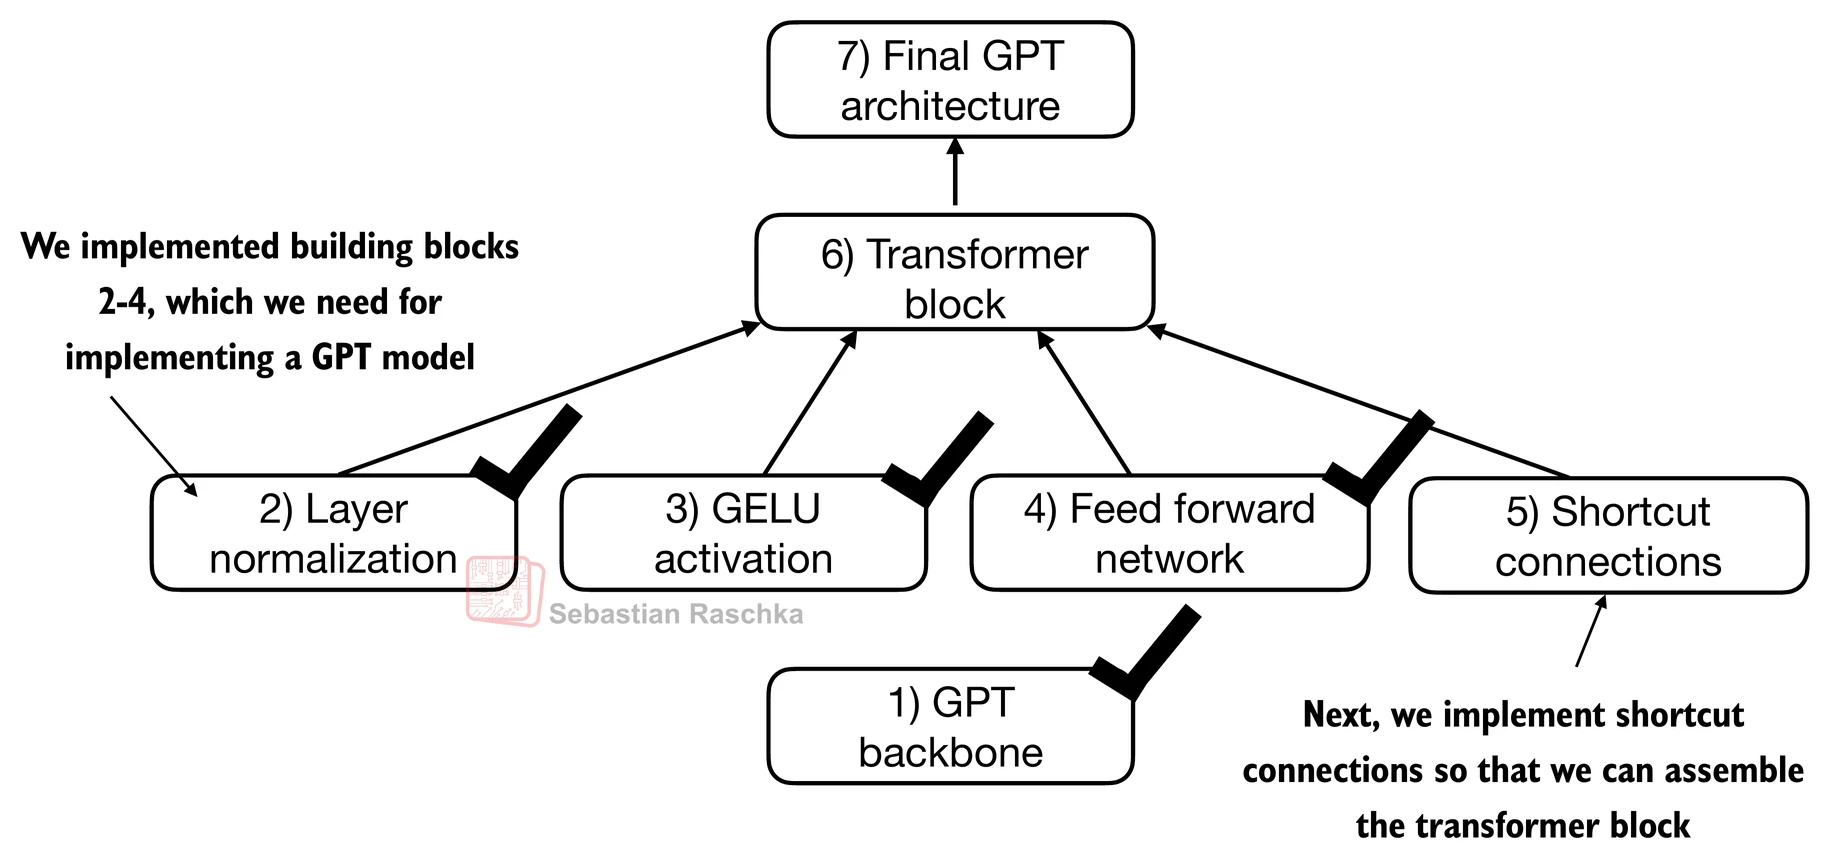

## **Adding Shortcut connections**

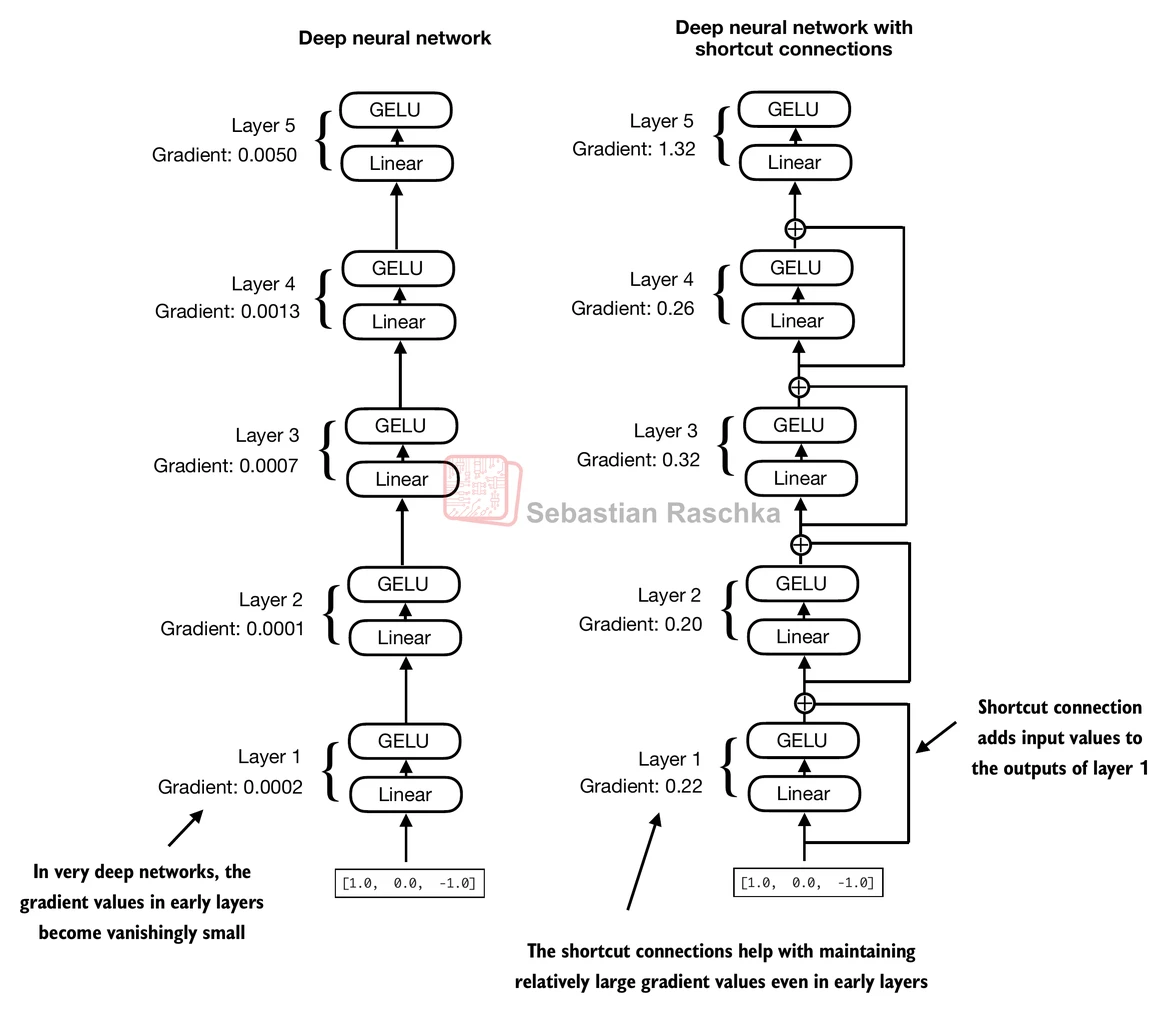

#### Without shortcut

In [10]:
from GPT_Model_architecture_class import ExampleDeepNeuralNetwork, print_gradients

layer_sizes = [3,3,3,3,3,1]
sample_input = torch.tensor([[1., 0., -1.]])#1 sample, 3 features

torch.manual_seed(123)

model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


With this code you can see the first layer gradient is really smalle -> vanishing gradient problem 

#### With Shortcut

In [11]:
torch.manual_seed(123)

model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732502937317
layers.4.0.weight has gradient mean of 1.3258541822433472


last layer does have a higher gradient but the first layer is stablized unlike before 